# 260520/21 — Density-MAE inspection

Pulls a checkpoint, runs it on a val sample, and visualizes:

1. **Density** — ground truth (clean blur of atom voxels) vs masked input vs model prediction.
2. **Structure** — target ligand+pocket atom voxels vs predicted (channel sums).
3. **Per-channel atoms** — 11 channels target vs predicted (lig: 7, poc: 4).
4. **Quantitative split** — per-source MSE on atoms-present vs background voxels (catches the constant-zero shortcut).

Mask ratio 0.6, block size 8³ vox (= 2³ Å). All numbers are per-voxel z-scored.

Default `EXP_DIR` points at the **v2** run `260521_density_mae_posweight/` (added `struct_pos_weight=100` after 260520's structure head collapsed to ~0 — see per-source split in cell 6). Point `EXP_DIR` at the old run to compare.

Inputs to tweak at the top: `EXP_DIR`, `SAMPLE_IDX`, `SLICE_AXIS`, `SEED_MASK`.

In [ ]:
# ── imports + paths ──────────────────────────────────────────────────────
import sys, os
VOX_ROOT = '/home/shpark/prj-denovo/VoxBind'
if VOX_ROOT not in sys.path:
    sys.path.insert(0, VOX_ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

from voxbind.models.density_mae import (
    DensityMAE, gaussian_blur3d, per_sample_zscore,
)
from voxbind.dataset.crossdocked import DatasetCrossdocked
from voxbind.voxelizer import Voxelizer

device = torch.device('cuda:7' if torch.cuda.is_available() else 'cpu')
torch.set_grad_enabled(False)
print('device:', device)

In [ ]:
# ── knobs ────────────────────────────────────────────────────────────────
EXP_DIR = f'{VOX_ROOT}/voxbind/exps/260521_density_mae_posweight'   # v2: pos-weighted L_str
# EXP_DIR = f'{VOX_ROOT}/voxbind/exps/260520_density_mae_pretrain'  # v1: original, struct head broken
CKPT_PATH = f'{EXP_DIR}/checkpoint.pth.tar'   # or checkpoint_e0010.pth.tar etc.
DATA_DIR = f'{VOX_ROOT}/voxbind/dataset/data'

SAMPLE_IDX = 7        # which val sample to visualize (0..99)
SLICE_AXIS = 'z'      # 'x', 'y', or 'z' — orthogonal slice axis
SLICE_OFFSET = 0      # offset from grid center (in voxels)
SEED_MASK = 0         # reproducible block mask
SEED_NOISE = 1        # reproducible additive noise

# These mirror the training config (configs/config_train_density_mae.yaml > mae)
SIGMA_BLUR_A = 0.55   # midpoint of [0.30, 0.80] Å
SIGMA_NOISE = 0.05
BLOCK_SIZE = 8
MASK_RATIO = 0.60
RESOLUTION = 0.25     # Å / voxel
GRID_DIM = 64
STRUCT_POS_THRESH = 0.05   # voxel counts as 'atom present' for the on/off split below
print(f'σ_blur = {SIGMA_BLUR_A} Å = {SIGMA_BLUR_A / RESOLUTION:.2f} vox')

σ_blur = 0.55 Å = 2.20 vox


In [ ]:
# ── load model from checkpoint ───────────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
cfg = ckpt['cfg'] if 'cfg' in ckpt else None
print('ckpt epoch:', ckpt.get('epoch'), '| global_step:', ckpt.get('global_step'))
if cfg is not None:
    print('model cfg:', OmegaConf.to_container(cfg.model, resolve=True))

model = DensityMAE(
    n_channels=cfg.model.n_channels if cfg is not None else 32,
    n_blocks=cfg.model.n_blocks if cfg is not None else 4,
    n_groups=cfg.model.n_groups if cfg is not None else 16,
    dropout=cfg.model.dropout if cfg is not None else 0.1,
).to(device).eval()

sd = ckpt.get('state_dict_ema', ckpt.get('state_dict'))
sd = {k.replace('module.', '').replace('_orig_mod.', ''): v for k, v in sd.items()}
missing, unexpected = model.load_state_dict(sd, strict=False)
print('missing keys:', len(missing), '| unexpected keys:', len(unexpected))
print(f'params: {sum(p.numel() for p in model.parameters()) / 1e6:.3f}M')

ckpt epoch: 42 | global_step: 44720
model cfg: {'model_name': 'density_mae', 'n_channels': 32, 'n_blocks': 4, 'n_groups': 16, 'dropout': 0.1, 'n_struct_channels': 11}
missing keys: 0 | unexpected keys: 0
params: 0.075M


In [ ]:
# ── load + voxelize one val sample ───────────────────────────────────────
dset_val = DatasetCrossdocked(
    data_dir=DATA_DIR, split='val', aug=False, small=False,
    ligand_radius=0.5, pocket_radius=-1,
)
print('val set size:', len(dset_val))
sample = dset_val[SAMPLE_IDX]
print('sample id:', sample['ligand']['id'], '|', sample['pocket']['id'])

# Voxelizer expects a batched dict — stack a single sample.
voxelizer = Voxelizer(
    grid_dim=GRID_DIM, resolution=RESOLUTION, cubes_around=8, device=device,
)
lig = {k: sample['ligand'][k].unsqueeze(0).to(device)
       for k in ('coords', 'radius', 'atoms_channel')}
poc = {k: sample['pocket'][k].unsqueeze(0).to(device)
       for k in ('coords', 'radius', 'atoms_channel')}
v_lig = voxelizer(lig, num_channels=7)      # (1, 7, G, G, G)
v_poc = voxelizer(poc, num_channels=4)      # (1, 4, G, G, G)
print('v_lig:', tuple(v_lig.shape), 'v_poc:', tuple(v_poc.shape))

val set size: 100
sample id: BRD9_HUMAN_133_241_0/4yyg_A_rec_4nqn_y1z_lig_tt_docked_1.sdf | BRD9_HUMAN_133_241_0/4yyg_A_rec_4nqn_y1z_lig_tt_docked_1_pocket10.pdb
v_lig: (1, 7, 64, 64, 64) v_poc: (1, 4, 64, 64, 64)


In [ ]:
# ── build synthetic density + mask (same recipe as the trainer) ──────────
g_mask = torch.Generator(device=device).manual_seed(SEED_MASK)
g_noise = torch.Generator(device=device).manual_seed(SEED_NOISE)

atoms_sum = v_lig.sum(dim=1, keepdim=True) + v_poc.sum(dim=1, keepdim=True)  # (1,1,G,G,G)
sigma_vox = SIGMA_BLUR_A / RESOLUTION
d_clean = gaussian_blur3d(atoms_sum, sigma_vox)
d_clean = per_sample_zscore(d_clean)
d_noisy = d_clean + torch.randn(d_clean.shape, device=device, generator=g_noise) * SIGMA_NOISE

# Block mask (same as make_block_mask but with seeded RNG)
gb = GRID_DIM // BLOCK_SIZE
blocks = torch.rand(1, 1, gb, gb, gb, device=device, generator=g_mask) < MASK_RATIO
mask = blocks.repeat_interleave(BLOCK_SIZE, 2)\
             .repeat_interleave(BLOCK_SIZE, 3)\
             .repeat_interleave(BLOCK_SIZE, 4)
d_in = d_noisy * (~mask).to(d_noisy.dtype)
target_str = torch.cat([v_lig, v_poc], dim=1)   # (1, 11, G, G, G)

print(f'mask fraction: {mask.float().mean().item():.3f}  '
      f'(target {MASK_RATIO})')
print(f'd_clean stats: mean={d_clean.mean().item():+.3f}  std={d_clean.std().item():.3f}  '
      f'min={d_clean.min().item():+.2f}  max={d_clean.max().item():+.2f}')

mask fraction: 0.580  (target 0.6)
d_clean stats: mean=+0.000  std=1.000  min=-0.83  max=+3.63


In [ ]:
# ── forward through the model ────────────────────────────────────────────
d_hat, a_hat = model(d_in)
print('d_hat:', tuple(d_hat.shape), 'a_hat:', tuple(a_hat.shape))

# Per-sample metrics for this single example
m = mask.float()
L_dens_masked = (((d_hat - d_clean) ** 2) * m).sum() / m.sum().clamp(min=1)
L_str_all    = ((a_hat - target_str) ** 2).mean()
print(f'sample L_dens (masked only): {L_dens_masked.item():.5f}')
print(f'sample L_str  (all voxels):  {L_str_all.item():.5f}')

# Per-source on/off split — the diagnostic that caught 260520's constant-zero
# shortcut. If MSE@on is huge while MSE@off ≈ 0 and pred-peak ≪ tgt-peak,
# the structure head has collapsed to outputting ~0 everywhere.
print(f'\nper-source split (threshold {STRUCT_POS_THRESH}):')
for name, tgt, pred in [
    ('lig', target_str[0, :7], a_hat[0, :7]),
    ('poc', target_str[0, 7:], a_hat[0, 7:]),
]:
    pos = tgt > STRUCT_POS_THRESH
    pos_frac = pos.float().mean().item()
    mse_on  = ((pred[pos]  - tgt[pos])  ** 2).mean().item() if pos.any() else float('nan')
    mse_off = ((pred[~pos] - tgt[~pos]) ** 2).mean().item()
    print(
        f'  {name}: pos-frac={pos_frac:.4f}  '
        f'peak tgt={tgt.max().item():.3f} pred={pred.max().item():.3f}  '
        f'MSE@on={mse_on:.4f}  MSE@off={mse_off:.6f}'
    )

d_hat: (1, 1, 64, 64, 64) a_hat: (1, 11, 64, 64, 64)
sample L_dens (masked only): 0.01542
sample L_str  (all voxels):  0.00621

per-source split (threshold 0.05):
  lig: pos-frac=0.0028  peak tgt=0.992 pred=0.522  MSE@on=0.0320  MSE@off=0.001181
  poc: pos-frac=0.2091  peak tgt=1.000 pred=1.090  MSE@on=0.0160  MSE@off=0.014568


In [ ]:
# ── slicing helper ───────────────────────────────────────────────────────
def take_slice(vol, axis='z', offset=0):
    """vol: (G, G, G) torch or numpy. Returns 2D slice through the chosen axis."""
    arr = vol.detach().cpu().numpy() if torch.is_tensor(vol) else vol
    G = arr.shape[-1]
    idx = G // 2 + offset
    if axis == 'x':
        return arr[idx, :, :]
    elif axis == 'y':
        return arr[:, idx, :]
    elif axis == 'z':
        return arr[:, :, idx]
    raise ValueError(axis)

def show(ax, img, title, cmap='gray', vmin=None, vmax=None):
    im = ax.imshow(img.T, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    return im

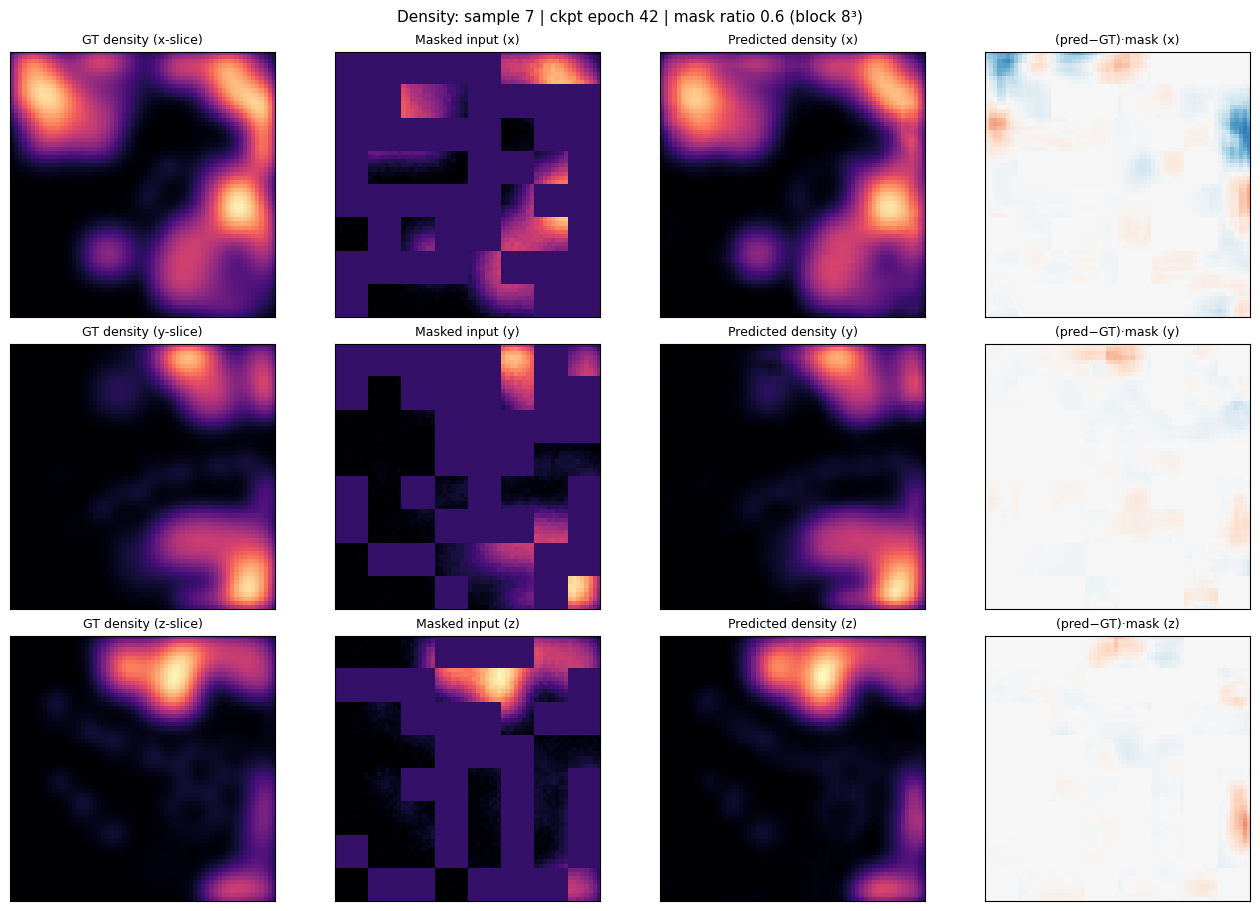

In [ ]:
# ── plot 1: density — ground truth | masked input | predicted | diff ────
d_clean_3d = d_clean[0, 0]
d_in_3d    = d_in[0, 0]
d_hat_3d   = d_hat[0, 0]
mask_3d    = mask[0, 0]

# Use d_clean's range so masked input / prediction are comparable
vlo = d_clean_3d.min().item()
vhi = d_clean_3d.max().item()

fig, axes = plt.subplots(3, 4, figsize=(13, 9), constrained_layout=True)
for i, ax_name in enumerate(['x', 'y', 'z']):
    show(axes[i, 0], take_slice(d_clean_3d, ax_name, SLICE_OFFSET),
         f'GT density ({ax_name}-slice)', cmap='magma', vmin=vlo, vmax=vhi)
    show(axes[i, 1], take_slice(d_in_3d, ax_name, SLICE_OFFSET),
         f'Masked input ({ax_name})', cmap='magma', vmin=vlo, vmax=vhi)
    show(axes[i, 2], take_slice(d_hat_3d, ax_name, SLICE_OFFSET),
         f'Predicted density ({ax_name})', cmap='magma', vmin=vlo, vmax=vhi)
    diff = (d_hat_3d - d_clean_3d) * mask_3d.float()  # only show error on masked voxels
    show(axes[i, 3], take_slice(diff, ax_name, SLICE_OFFSET),
         f'(pred−GT)·mask ({ax_name})', cmap='RdBu_r', vmin=-1.5, vmax=1.5)
fig.suptitle(
    f"Density: sample {SAMPLE_IDX} | ckpt epoch {ckpt.get('epoch')} | "
    f"mask ratio {MASK_RATIO} (block {BLOCK_SIZE}³)",
    fontsize=11,
)
plt.show()

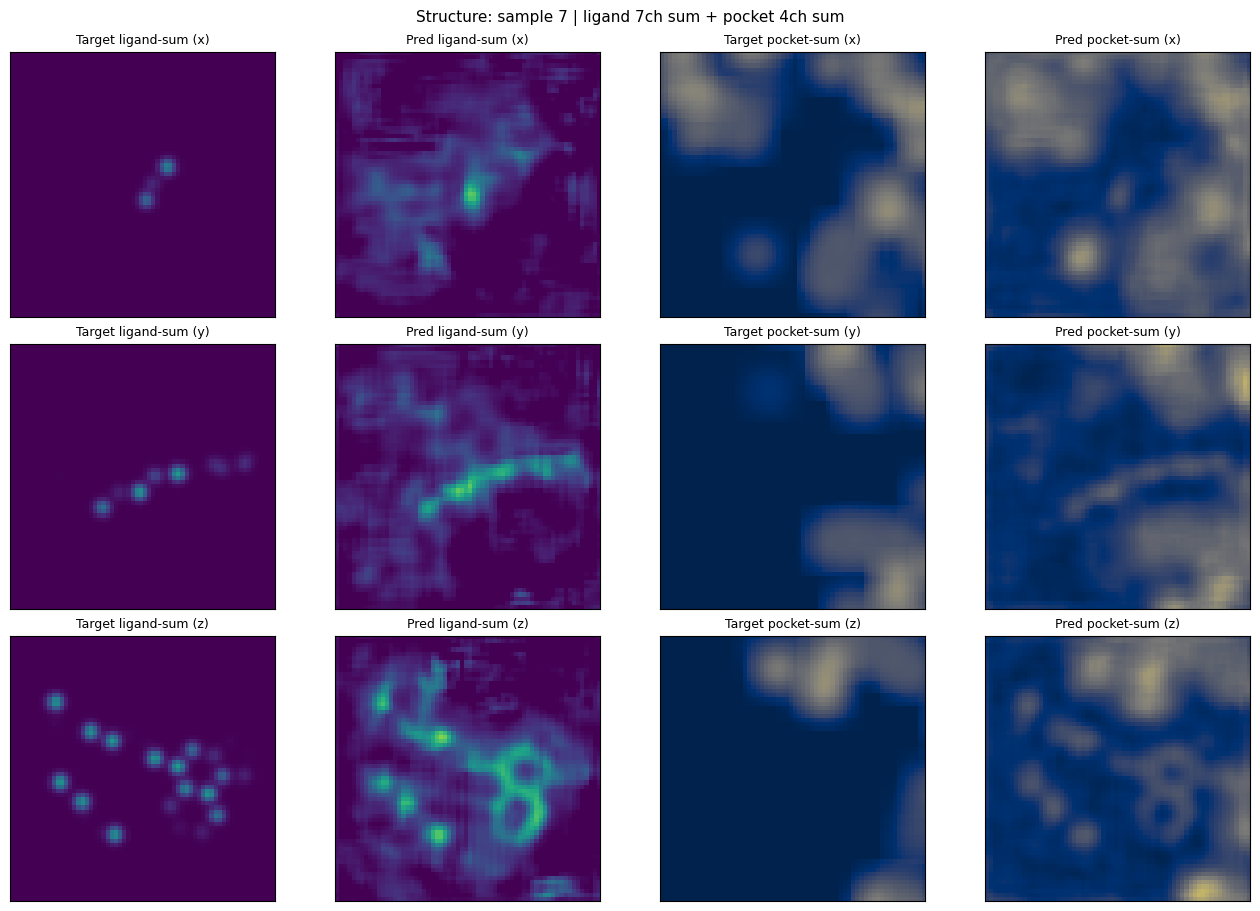

In [ ]:
# ── plot 2: structure — ligand-sum and pocket-sum, target vs predicted ──
tgt_lig = target_str[0, :7].sum(0)
tgt_poc = target_str[0, 7:].sum(0)
pred_lig = a_hat[0, :7].sum(0)
pred_poc = a_hat[0, 7:].sum(0)

vmax_lig = max(tgt_lig.max().item(), pred_lig.max().item())
vmax_poc = max(tgt_poc.max().item(), pred_poc.max().item())

fig, axes = plt.subplots(3, 4, figsize=(13, 9), constrained_layout=True)
for i, ax_name in enumerate(['x', 'y', 'z']):
    show(axes[i, 0], take_slice(tgt_lig, ax_name, SLICE_OFFSET),
         f'Target ligand-sum ({ax_name})', cmap='viridis', vmin=0, vmax=vmax_lig)
    show(axes[i, 1], take_slice(pred_lig, ax_name, SLICE_OFFSET),
         f'Pred ligand-sum ({ax_name})', cmap='viridis', vmin=0, vmax=vmax_lig)
    show(axes[i, 2], take_slice(tgt_poc, ax_name, SLICE_OFFSET),
         f'Target pocket-sum ({ax_name})', cmap='cividis', vmin=0, vmax=vmax_poc)
    show(axes[i, 3], take_slice(pred_poc, ax_name, SLICE_OFFSET),
         f'Pred pocket-sum ({ax_name})', cmap='cividis', vmin=0, vmax=vmax_poc)
fig.suptitle(
    f"Structure: sample {SAMPLE_IDX} | ligand 7ch sum + pocket 4ch sum",
    fontsize=11,
)
plt.show()

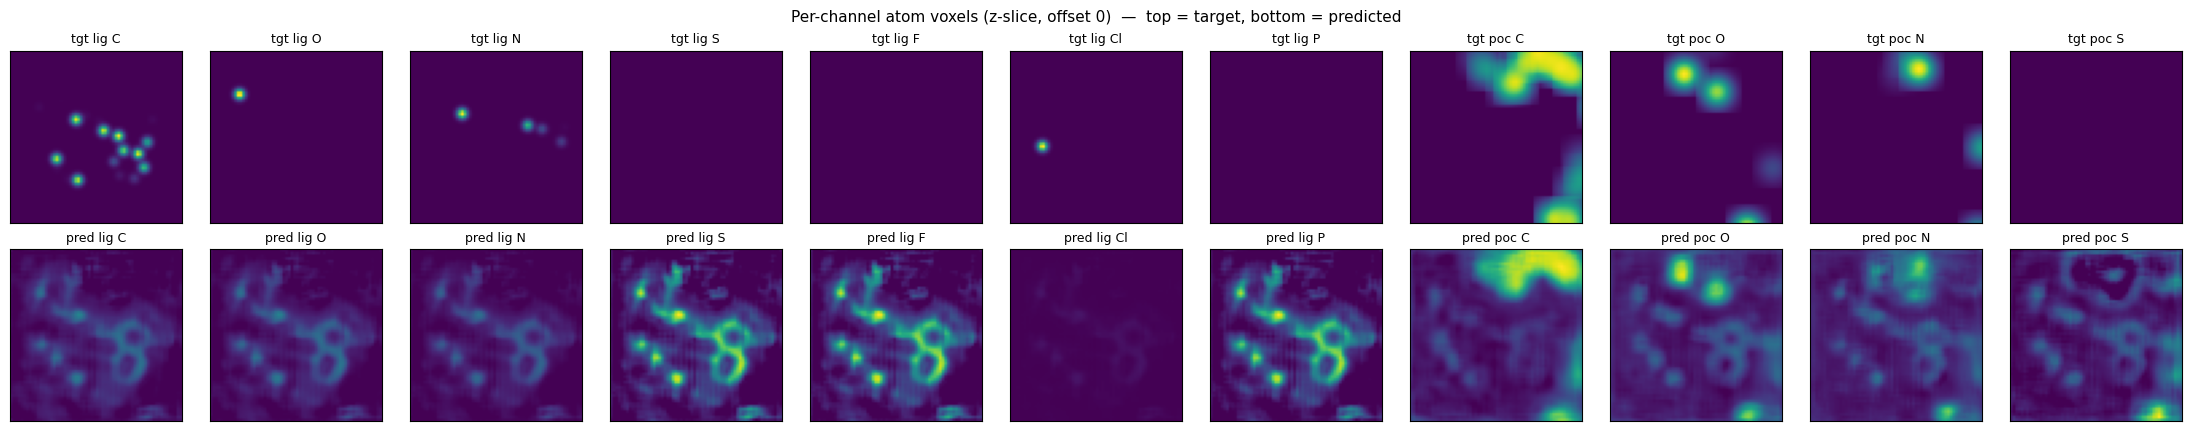

In [ ]:
# ── plot 3: all 11 channels — target (top) vs predicted (bottom) ────────
# z-center slice each — useful to see WHICH atom types are well predicted.
from voxbind.constants import ELEMENTS_HASH_CROSSDOCKED
# Pocket channels = first 4 elements; ligand channels = first 7 elements
elem_names = list(ELEMENTS_HASH_CROSSDOCKED.keys())
lig_names = [f'lig {elem_names[i]}' for i in range(7)]
poc_names = [f'poc {elem_names[i]}' for i in range(4)]
chan_names = lig_names + poc_names

fig, axes = plt.subplots(2, 11, figsize=(22, 4.2), constrained_layout=True)
for c in range(11):
    tgt = take_slice(target_str[0, c], SLICE_AXIS, SLICE_OFFSET)
    pred = take_slice(a_hat[0, c], SLICE_AXIS, SLICE_OFFSET)
    vmax = max(tgt.max(), pred.max(), 1e-3)
    show(axes[0, c], tgt, f'tgt {chan_names[c]}', cmap='viridis', vmin=0, vmax=vmax)
    show(axes[1, c], pred, f'pred {chan_names[c]}', cmap='viridis', vmin=0, vmax=vmax)
fig.suptitle(
    f"Per-channel atom voxels ({SLICE_AXIS}-slice, offset {SLICE_OFFSET})  —  "
    f"top = target, bottom = predicted",
    fontsize=11,
)
plt.show()

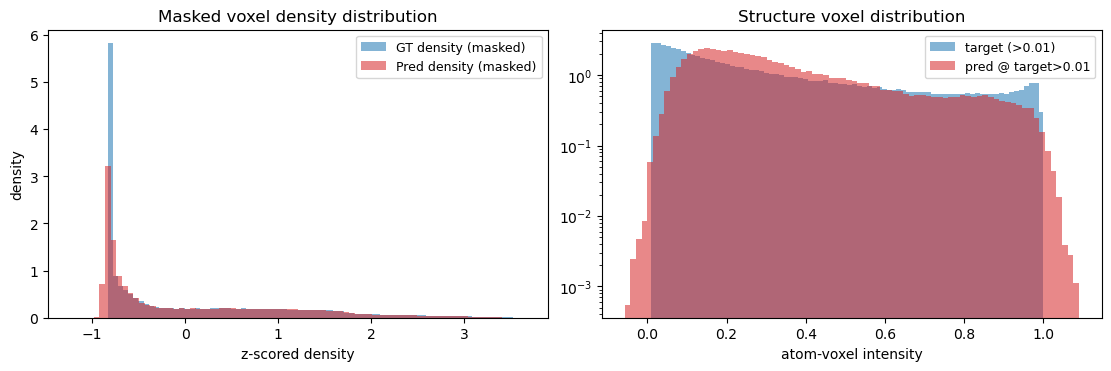

In [ ]:
# ── histogram: pred vs target voxel-value distributions ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)

# Density: only the masked voxels (that's what the loss optimizes)
m_flat = mask_3d.bool().flatten().cpu()
gt_d = d_clean_3d.flatten().cpu()[m_flat].numpy()
pr_d = d_hat_3d.flatten().cpu()[m_flat].numpy()
axes[0].hist(gt_d, bins=80, alpha=0.55, label='GT density (masked)', color='C0', density=True)
axes[0].hist(pr_d, bins=80, alpha=0.55, label='Pred density (masked)', color='C3', density=True)
axes[0].set_xlabel('z-scored density'); axes[0].set_ylabel('density')
axes[0].legend(fontsize=9); axes[0].set_title('Masked voxel density distribution')

# Structure: 'on'-voxels mostly
gt_a = target_str.flatten().cpu().numpy()
pr_a = a_hat.flatten().cpu().numpy()
axes[1].hist(gt_a[gt_a > 0.01], bins=80, alpha=0.55, label='target (>0.01)',
             color='C0', density=True)
axes[1].hist(pr_a[gt_a > 0.01], bins=80, alpha=0.55, label='pred @ target>0.01',
             color='C3', density=True)
axes[1].set_xlabel('atom-voxel intensity'); axes[1].set_yscale('log')
axes[1].legend(fontsize=9); axes[1].set_title('Structure voxel distribution')
plt.show()

## Notes

* `SAMPLE_IDX` ∈ [0, 99]. Re-run cells 4-end to swap sample.
* `CKPT_PATH` defaults to the rolling `checkpoint.pth.tar` — point to e.g. `checkpoint_e0030.pth.tar` to inspect a specific epoch.
* The mask is reproducible via `SEED_MASK` — change it to see different missing regions.
* The `(pred−GT)·mask` panel only shows error on masked voxels (the only ones the loss optimizes); un-masked voxels are zeroed out, so they appear black.
* For the per-channel plot, sparse channels (e.g. lig P, lig Cl) will mostly look empty unless the sample has those atoms.